In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers=['GFNORTEO.MX','ALSEA.MX','CEMEXCPO.MX','TLEVISACPO.MX','^MXX']

In [3]:
prices=yf.download(tickers,start='2022-01-01',end='2026-09-08')['Close']

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/664724799.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices=yf.download(tickers,start='2022-01-01',end='2026-09-08')['Close']
[*********************100%***********************]  5 of 5 completed


In [4]:
rets=prices.pct_change().dropna()

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/2986316400.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets=prices.pct_change().dropna()


In [5]:
cov=rets.cov()
cov

Ticker,ALSEA.MX,CEMEXCPO.MX,GFNORTEO.MX,TLEVISACPO.MX,^MXX
Ticker,,,,,
ALSEA.MX,0.000351,0.000099,0.000099,0.000098,0.000075
CEMEXCPO.MX,0.000099,0.000486,0.000122,0.000181,0.000131
GFNORTEO.MX,0.000099,0.000122,0.000381,0.000098,0.000125
TLEVISACPO.MX,0.000098,0.000181,0.000098,0.000746,0.000108
^MXX,0.000075,0.000131,0.000125,0.000108,0.000100


In [6]:
#FORMULA DE BETA 
#la beta es como se mueve el activo en relacion al mercado, es decir, si el mercado sube 1% cuanto sube el activo
#el CAPM a mayor riesgo sistematico mayor es la beta, y a mayor beta mayor es el rendimiento esperado del activo
#rm rendimiento de mercado y rf es tasa libre de riesgo
betas=cov.loc['^MXX']/cov.loc['^MXX','^MXX']
betas

Ticker
ALSEA.MX         0.751996
CEMEXCPO.MX      1.312818
GFNORTEO.MX      1.248861
TLEVISACPO.MX    1.080552
^MXX             1.000000
Name: ^MXX, dtype: float64

In [7]:
#Rendimiento esperado del mercado IPC
R_m=rets['^MXX'].mean()*252
R_m

np.float64(0.05565362340518652)

In [8]:
r_f=0.05

In [9]:
E_R= r_f + betas*(R_m-r_f)
E_R*100

Ticker
ALSEA.MX         5.425150
CEMEXCPO.MX      5.742218
GFNORTEO.MX      5.706059
TLEVISACPO.MX    5.610903
^MXX             5.565362
Name: ^MXX, dtype: float64

In [10]:
rend_real=rets.mean()*252
rend_real

Ticker
ALSEA.MX         0.069625
CEMEXCPO.MX      0.129130
GFNORTEO.MX      0.218876
TLEVISACPO.MX   -0.198833
^MXX             0.055654
dtype: float64

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/974836933.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(betas[i],E_R[i], label=prices.columns[i])
/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/974836933.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(betas[i],rend_real[i], label=prices.columns[i], marker='x')


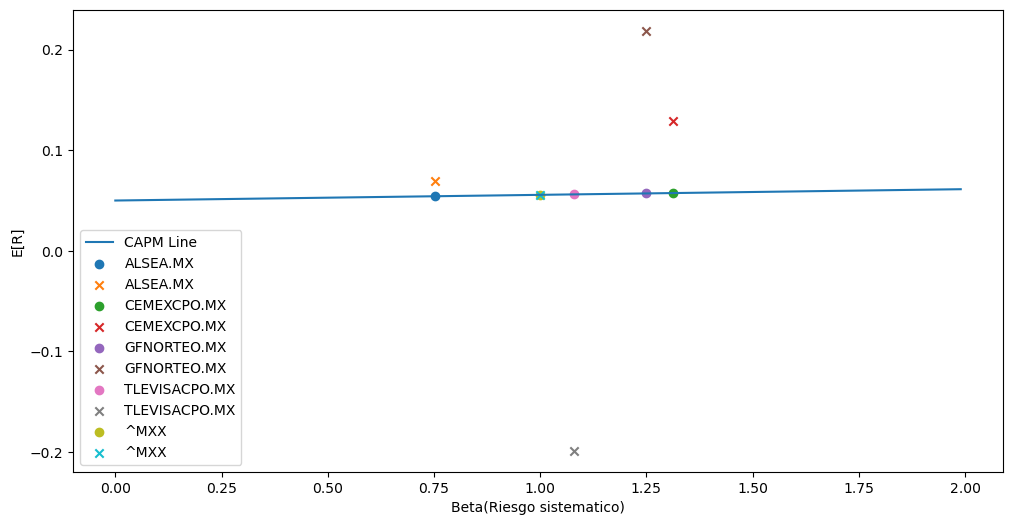

In [11]:
#Grafico
space_betas=np.arange(0,2,0.01)
space_E_R=r_f + space_betas*(R_m-r_f)

plt.figure(figsize=(12,6))
plt.plot(space_betas,space_E_R, label='CAPM Line')
for i in range (len(betas)):
    plt.scatter(betas[i],E_R[i], label=prices.columns[i])
    plt.scatter(betas[i],rend_real[i], label=prices.columns[i], marker='x')
plt.legend()
plt.xlabel('Beta(Riesgo sistematico)')
plt.ylabel('E[R]')
plt.show();

## ACTIVIDAD

In [12]:
tickers=['AMZN','TSLA','^GSPC']

In [13]:
prices=yf.download(tickers,start='2022-01-01',end='2026-09-08')['Close']

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/664724799.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices=yf.download(tickers,start='2022-01-01',end='2026-09-08')['Close']
[*********************100%***********************]  3 of 3 completed


In [14]:
rets=prices.pct_change().dropna()

In [15]:
cov=rets.cov()
cov

Ticker,AMZN,TSLA,^GSPC
Ticker,,,
AMZN,0.000549,0.000397,0.000180
TSLA,0.000397,0.001424,0.000244
^GSPC,0.000180,0.000244,0.000118


In [16]:
#FORMULA DE BETA 
#la beta es como se mueve el activo en relacion al mercado, es decir, si el mercado sube 1% cuanto sube el activo
#el CAPM a mayor riesgo sistematico mayor es la beta, y a mayor beta mayor es el rendimiento esperado del activo
#rm rendimiento de mercado y rf es tasa libre de riesgo
betas=cov.loc['^GSPC']/cov.loc['^GSPC','^GSPC']
betas

Ticker
AMZN     1.527860
TSLA     2.073596
^GSPC    1.000000
Name: ^GSPC, dtype: float64

In [17]:
#Rendimiento esperado del mercado IPC
R_m=rets['^GSPC'].mean()*252
R_m

np.float64(0.11713676257209715)

In [18]:
r_f=0.05

In [19]:
E_R= r_f + betas*(R_m-r_f)
E_R*100

Ticker
AMZN     15.257557
TSLA     18.921455
^GSPC    11.713676
Name: ^GSPC, dtype: float64

In [20]:
rend_real=rets.mean()*252
rend_real

Ticker
AMZN     0.158382
TSLA     0.152559
^GSPC    0.117137
dtype: float64

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/974836933.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(betas[i],E_R[i], label=prices.columns[i])
/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_34423/974836933.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(betas[i],rend_real[i], label=prices.columns[i], marker='x')


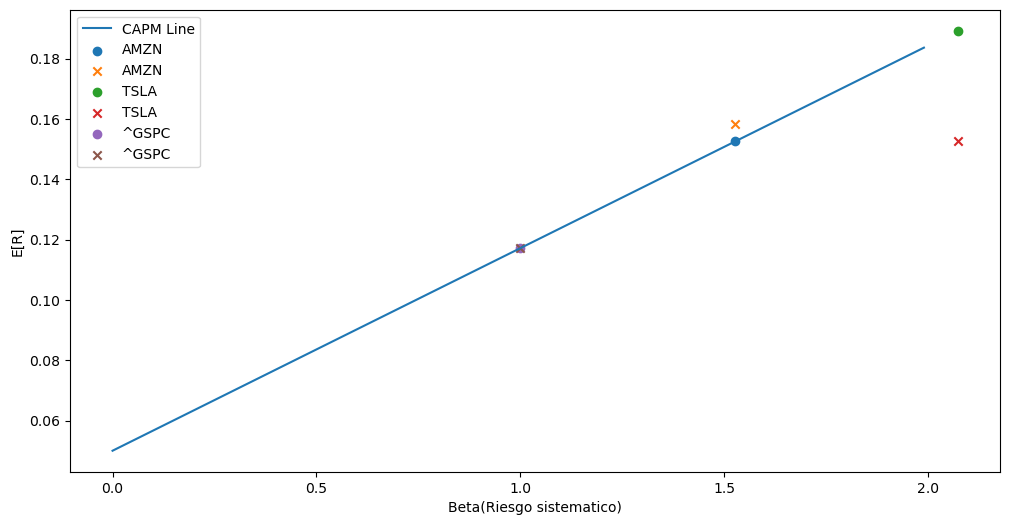

In [21]:
#Grafico
space_betas=np.arange(0,2,0.01)
space_E_R=r_f + space_betas*(R_m-r_f)

plt.figure(figsize=(12,6))
plt.plot(space_betas,space_E_R, label='CAPM Line')
for i in range (len(betas)):
    plt.scatter(betas[i],E_R[i], label=prices.columns[i])
    plt.scatter(betas[i],rend_real[i], label=prices.columns[i], marker='x')
plt.legend()
plt.xlabel('Beta(Riesgo sistematico)')
plt.ylabel('E[R]')
plt.show();